# Capítulo 038 — Integrar un análisis exploratorio completo

## Unir las piezas del análisis exploratorio

Hasta ahora trabajamos muchas herramientas por separado: inspección inicial de datos, resúmenes estadísticos, conteos, agrupaciones, tablas de resumen y distintos tipos de gráficos.

En este capítulo vamos a integrar esas herramientas en un recorrido más completo de análisis exploratorio. La idea no es aprender una función nueva, sino practicar cómo combinar lo que ya sabemos para responder preguntas sobre un dataset.

Vamos a seguir usando el dataset `tips`, porque ya conocemos sus columnas y eso nos permite concentrarnos en el proceso de análisis. El objetivo será construir una lectura ordenada: primero observar la estructura general, después plantear algunas preguntas, luego calcular resúmenes y visualizaciones, y finalmente escribir hallazgos prudentes.

Un análisis exploratorio no busca cerrar una verdad definitiva. Busca conocer mejor los datos, detectar patrones, encontrar diferencias interesantes y reconocer límites de interpretación.

## Cargar el dataset

Comenzamos importando las librerías necesarias y cargando el dataset `tips`. Después de cargarlo, vamos a mirar las primeras filas para recordar qué información contiene cada registro.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset `tips`. Cada fila representa una cuenta registrada en un restaurante e incluye información sobre el importe total de la cuenta, la propina, el día, el horario, el tamaño del grupo y algunas variables categóricas.

Como este capítulo busca integrar herramientas, no vamos a analizar una sola columna de manera aislada desde el comienzo. Primero vamos a hacer una revisión general del dataset para recordar cuántas filas y columnas tiene, qué tipos de datos aparecen y si hay valores faltantes.

## Revisar la estructura general

Antes de calcular promedios o construir gráficos, conviene revisar la estructura del dataset. Esta etapa inicial nos ayuda a entender con qué datos estamos trabajando y a detectar posibles problemas básicos.

Vamos a consultar la cantidad de filas y columnas, y luego vamos a usar `info()` para ver los nombres de las columnas, los tipos de datos y la cantidad de valores no nulos.

In [2]:
df.shape

(244, 7)

El resultado `(244, 7)` indica que el dataset tiene 244 filas y 7 columnas.

En este contexto, cada fila representa una cuenta registrada en el restaurante, y cada columna representa una característica de esa cuenta. Esta primera revisión nos da una idea del tamaño general del dataset: no estamos trabajando con una tabla enorme, pero sí con suficientes registros como para explorar patrones, comparaciones y relaciones entre variables.

Ahora vamos a mirar información más detallada sobre las columnas.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


La salida de `info()` permite revisar varias cosas importantes. El dataset tiene 244 registros y todas las columnas tienen 244 valores no nulos, por lo que no aparecen valores faltantes en esta primera revisión.

También podemos distinguir dos tipos principales de variables. Por un lado, hay variables numéricas: `total_bill`, `tip` y `size`. Por otro lado, hay variables categóricas: `sex`, `smoker`, `day` y `time`.

Esta distinción es importante porque no analizamos todas las columnas de la misma manera. Para las variables numéricas podemos calcular medidas como promedio, mediana, mínimo y máximo. Para las variables categóricas, en cambio, suele ser más útil contar cuántas veces aparece cada categoría.

Con esta estructura general clara, podemos plantear algunas preguntas de análisis.

## Plantear preguntas de análisis

Un análisis exploratorio suele empezar con preguntas. No hace falta que sean preguntas definitivas ni demasiado complejas; sirven como guía para decidir qué tablas y gráficos construir.

En este capítulo vamos a trabajar con algunas preguntas simples:

- ¿cómo se distribuyen los importes de las cuentas?
- ¿cómo se distribuyen las propinas?
- ¿qué días y horarios tienen más registros?
- ¿los importes cambian según el día o el horario?
- ¿hay relación entre el importe total de la cuenta y la propina?

Estas preguntas nos van a permitir recorrer variables numéricas, variables categóricas, comparaciones entre grupos y relaciones entre variables.

## Resumir las variables numéricas

Vamos a empezar por las variables numéricas. Un resumen estadístico nos permite tener una primera idea de sus valores centrales, su dispersión y sus rangos.

En este dataset, las variables numéricas principales son `total_bill`, `tip` y `size`.

In [4]:
columnas_numericas = ["total_bill", "tip", "size"]

df[columnas_numericas].describe().round(2)

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


El resumen estadístico muestra que hay 244 valores para cada variable numérica, lo cual coincide con la revisión anterior: no hay valores faltantes en estas columnas.

En `total_bill`, el importe promedio de la cuenta es 19.79 y la mediana es 17.80. Como el promedio es mayor que la mediana, esto sugiere que algunos importes altos pueden estar elevando el promedio. El valor máximo es 50.81, bastante por encima del tercer cuartil, que es 24.13.

En `tip`, el promedio es 3.00 y la mediana es 2.90. Los valores centrales están más cerca entre sí, aunque también aparece una propina máxima de 10.00, bastante más alta que el tercer cuartil de 3.56.

La variable `size` indica el tamaño del grupo. La mediana es 2, lo que sugiere que muchas cuentas corresponden a grupos de dos personas. Sin embargo, el valor máximo llega a 6, por lo que también hay algunos grupos más grandes.

Este resumen no responde todas las preguntas, pero nos da una base para decidir qué conviene mirar con más detalle.

## Contar las variables categóricas

Ahora vamos a revisar las variables categóricas. Para este tipo de columnas, una primera pregunta útil es cuántas veces aparece cada categoría.

Vamos a construir tablas de frecuencia para `day`, `time`, `sex` y `smoker`.

In [5]:
columnas_categoricas = ["day", "time", "sex", "smoker"]

for columna in columnas_categoricas:
    print(f"\nFrecuencias de {columna}:")
    print(df[columna].value_counts())


Frecuencias de day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Frecuencias de time:
time
Dinner    176
Lunch      68
Name: count, dtype: int64

Frecuencias de sex:
sex
Male      157
Female     87
Name: count, dtype: int64

Frecuencias de smoker:
smoker
No     151
Yes     93
Name: count, dtype: int64


Las tablas de frecuencia muestran que las categorías no están distribuidas de manera uniforme. En la columna `day`, el día con más registros es `Sat`, seguido por `Sun` y `Thur`; `Fri` tiene muchos menos registros que los demás días. En la columna `time`, hay muchas más cuentas de `Dinner` que de `Lunch`.

También vemos que en este dataset hay más registros asociados a `Male` que a `Female`, y más cuentas de no fumadores que de fumadores. Estas diferencias no son un problema, pero son importantes para interpretar cualquier comparación posterior.

Por ejemplo, si comparamos promedios por día, debemos recordar que `Fri` tiene solo 19 registros. Del mismo modo, si comparamos `Lunch` y `Dinner`, tenemos que considerar que `Dinner` tiene muchos más datos. En análisis exploratorio, las frecuencias ayudan a darle contexto a los promedios, gráficos y relaciones que vamos a mirar después.

## Visualizar la distribución de las cuentas

Después de revisar los resúmenes numéricos y las frecuencias, podemos mirar con más detalle una variable central del dataset: `total_bill`.

Vamos a construir un histograma para observar cómo se distribuyen los importes de las cuentas.

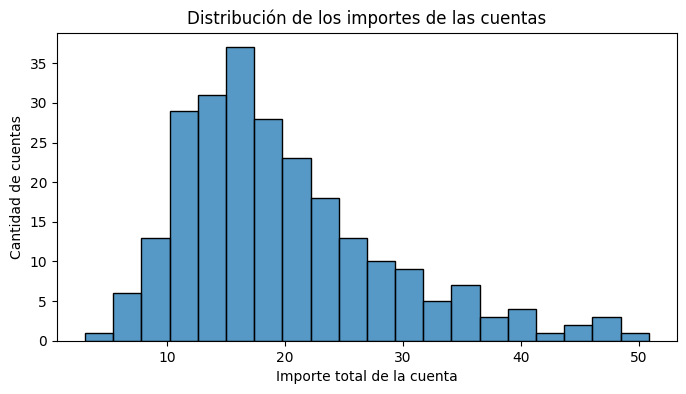

In [6]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="total_bill",
    bins=20
)

plt.title("Distribución de los importes de las cuentas")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Cantidad de cuentas")

plt.show()

El histograma muestra que la mayoría de las cuentas se concentra en importes bajos o medios, aproximadamente entre 10 y 25. A medida que los importes aumentan, la cantidad de cuentas disminuye.

También se observa una cola hacia la derecha: hay algunas cuentas con importes bastante más altos que el grupo principal, llegando a valores cercanos a 50. Esto ayuda a explicar por qué el promedio de `total_bill` era mayor que la mediana. Algunos valores altos empujan el promedio hacia arriba.

Esta visualización no reemplaza al resumen numérico, sino que lo complementa. La tabla nos dio valores concretos como promedio, mediana y máximo; el histograma nos permite ver la forma general de la distribución.

## Visualizar la distribución de las propinas

Ahora vamos a mirar la distribución de `tip`. Esta variable está relacionada con `total_bill`, pero conviene analizarla también por separado para entender cómo se comportan las propinas registradas en el dataset.

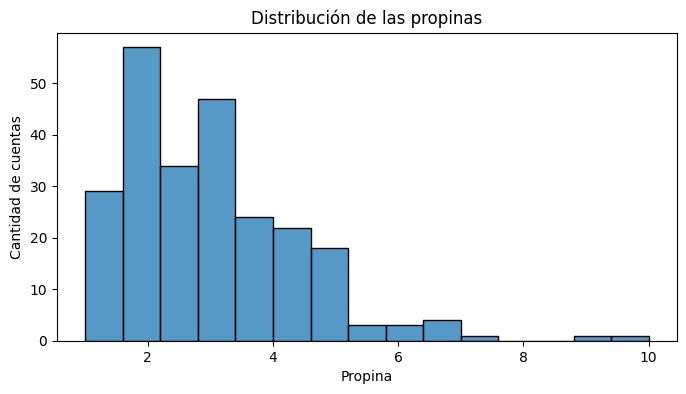

In [7]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="tip",
    bins=15
)

plt.title("Distribución de las propinas")
plt.xlabel("Propina")
plt.ylabel("Cantidad de cuentas")

plt.show()

El histograma de `tip` muestra que la mayoría de las propinas se concentra aproximadamente entre 1 y 5. Los valores más frecuentes aparecen alrededor de 2 y 3, mientras que las propinas más altas son mucho menos comunes.

También se observa una cola hacia la derecha. Hay algunos valores superiores a 6 y casos aislados cercanos a 9 o 10. Esto coincide con el resumen estadístico: la mediana era 2.90, el tercer cuartil era 3.56 y el valor máximo llegaba a 10.00.

Al integrar esta lectura con la distribución de `total_bill`, vemos una idea inicial: tanto los importes de las cuentas como las propinas se concentran en valores bajos o medios, con algunos valores altos menos frecuentes. Más adelante vamos a mirar si ambas variables se relacionan entre sí.

## Comparar importes según el día

Después de mirar distribuciones generales, podemos comparar grupos. Una pregunta útil es si el importe total de la cuenta cambia según el día.

Para eso vamos a calcular una tabla de resumen por día. Incluiremos la cantidad de cuentas, el promedio y la mediana de `total_bill`, porque no conviene interpretar un promedio sin saber cuántos datos lo sostienen.

In [8]:
orden_dias = ["Thur", "Fri", "Sat", "Sun"]

resumen_dia = (
    df.groupby("day", observed=True)
    .agg(
        cantidad_cuentas=("total_bill", "count"),
        promedio_cuenta=("total_bill", "mean"),
        mediana_cuenta=("total_bill", "median")
    )
    .reindex(orden_dias)
    .round(2)
    .reset_index()
)

resumen_dia

,day,cantidad_cuentas,promedio_cuenta,mediana_cuenta
0,Thur,62,17.68,16.20
1,Fri,19,17.15,15.38
2,Sat,87,20.44,18.24
3,Sun,76,21.41,19.63


La tabla muestra que `Sat` y `Sun` tienen los promedios de cuenta más altos. `Sun` presenta el promedio más alto, con 21.41, y también la mediana más alta, con 19.63. En cambio, `Thur` y `Fri` tienen promedios y medianas más bajos.

También es importante mirar la cantidad de cuentas. `Fri` tiene solo 19 registros, bastante menos que los demás días, por lo que sus valores deben interpretarse con más cuidado. `Sat` y `Sun`, en cambio, tienen más registros y eso hace que la comparación sea más estable.

Esta tabla resume bien la comparación, pero un gráfico puede ayudarnos a ver las diferencias de forma más rápida.

## Visualizar el promedio por día

Vamos a construir un gráfico de barras para comparar el promedio de `total_bill` según el día. Como este capítulo integra herramientas ya trabajadas, vamos a cuidar también la comunicación visual: usaremos un título claro, etiquetas descriptivas y valores sobre las barras.

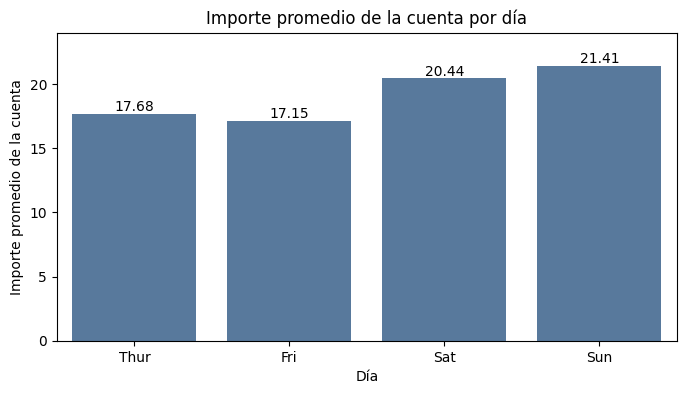

In [9]:
plt.figure(figsize=(8, 4))

grafico = sns.barplot(
    data=resumen_dia,
    x="day",
    y="promedio_cuenta",
    color="#4C78A8"
)

plt.title("Importe promedio de la cuenta por día")
plt.xlabel("Día")
plt.ylabel("Importe promedio de la cuenta")
plt.ylim(0, 24)

for barras in grafico.containers:
    grafico.bar_label(barras, fmt="%.2f")

plt.show()

El gráfico muestra que `Sat` y `Sun` tienen importes promedio más altos que `Thur` y `Fri`. La diferencia no es enorme, pero sí se observa un cambio entre los días de jueves y viernes, por un lado, y los días de fin de semana registrados, por otro.

Las etiquetas sobre las barras ayudan a leer los valores exactos sin depender solo del eje vertical. Aun así, este gráfico debe interpretarse junto con la tabla anterior, porque el promedio de cada día no está sostenido por la misma cantidad de registros. En particular, `Fri` tiene muchas menos cuentas que los demás días.

Hasta acá tenemos una primera comparación por día. Ahora vamos a sumar el horario para ver cómo se distribuyen las cuentas entre `Lunch` y `Dinner`.

## Analizar día y horario juntos

El dataset también permite combinar dos variables categóricas: `day` y `time`. Esta combinación es útil porque no todos los días tienen registros en ambos horarios.

Antes de graficar o comparar importes, conviene revisar cuántas cuentas hay en cada combinación de día y horario. Esto nos ayuda a evitar interpretaciones débiles basadas en grupos con muy pocos datos.

In [10]:
cuentas_dia_horario = pd.crosstab(
    df["day"],
    df["time"]
).reindex(orden_dias)

cuentas_dia_horario

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


La tabla muestra cuántas cuentas hay en cada combinación de día y horario. Esta información es clave para interpretar cualquier comparación posterior.

`Thur` aparece casi completamente asociado a `Lunch`: tiene 61 cuentas en almuerzo y solo 1 en cena. `Fri` tiene registros en ambos horarios, aunque son pocos en total. En cambio, `Sat` y `Sun` aparecen únicamente en `Dinner`, sin registros de `Lunch`.

Esto significa que no conviene comparar todas las combinaciones como si tuvieran la misma solidez. Por ejemplo, el único registro de `Dinner` en `Thur` no alcanza para hablar de una distribución o de un comportamiento típico. Del mismo modo, no podemos comparar almuerzos de `Sat` o `Sun` porque directamente no hay registros para esas combinaciones.

Ahora vamos a visualizar esta distribución de registros para que la diferencia entre días y horarios quede más clara.

## Visualizar cuentas por día y horario

Vamos a construir un gráfico de barras para mostrar la cantidad de cuentas en cada día, separando por horario. Esta visualización no busca analizar importes todavía; su objetivo es mostrar cuántos datos hay detrás de cada combinación.

Este paso es importante porque, en un análisis exploratorio completo, antes de comparar promedios o distribuciones conviene saber si los grupos tienen suficientes registros.

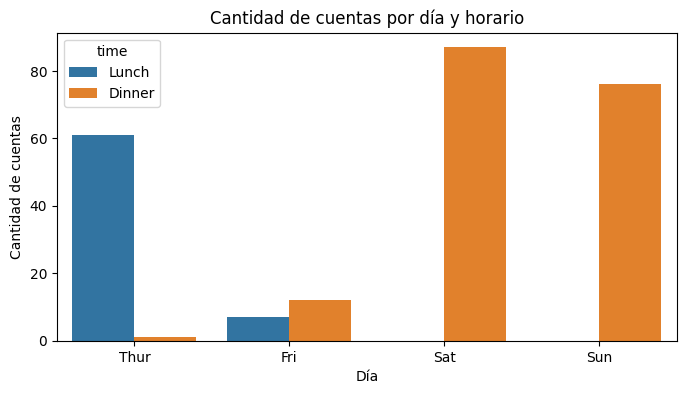

In [11]:
cuentas_dia_horario_grafico = (
    cuentas_dia_horario
    .reset_index()
    .melt(
        id_vars="day",
        var_name="time",
        value_name="cantidad_cuentas"
    )
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=cuentas_dia_horario_grafico,
    x="day",
    y="cantidad_cuentas",
    hue="time",
    order=orden_dias
)

plt.title("Cantidad de cuentas por día y horario")
plt.xlabel("Día")
plt.ylabel("Cantidad de cuentas")

plt.show()

El gráfico muestra la cantidad de cuentas por día y horario. La lectura visual confirma lo que ya aparecía en la tabla: `Thur` concentra casi todos sus registros en `Lunch`, `Sat` y `Sun` aparecen solo en `Dinner`, y `Fri` tiene pocos registros en ambos horarios.

Esta información es fundamental para el resto del análisis. Si más adelante observamos diferencias en importes promedio entre días u horarios, debemos recordar que no todos los grupos tienen la misma cantidad de datos. Algunas combinaciones, como `Thur` en `Dinner`, tienen tan pocos registros que no permiten una interpretación sólida.

En un análisis exploratorio completo, este tipo de revisión ayuda a evitar conclusiones apresuradas. No alcanza con ver que un grupo tiene un promedio alto o bajo: también necesitamos saber cuántas observaciones sostienen ese valor.

## Comparar importes por horario

Ya revisamos los días y la distribución de registros por día y horario. Ahora podemos volver a una comparación más general: el importe total de la cuenta según el horario.

Vamos a calcular una tabla de resumen para `Lunch` y `Dinner`, incluyendo cantidad de cuentas, promedio, mediana, mínimo y máximo de `total_bill`.

In [12]:
resumen_horario = (
    df.groupby("time", observed=True)
    .agg(
        cantidad_cuentas=("total_bill", "count"),
        promedio_cuenta=("total_bill", "mean"),
        mediana_cuenta=("total_bill", "median"),
        minimo_cuenta=("total_bill", "min"),
        maximo_cuenta=("total_bill", "max")
    )
    .round(2)
    .reset_index()
)

resumen_horario

,time,cantidad_cuentas,promedio_cuenta,mediana_cuenta,minimo_cuenta,maximo_cuenta
0,Lunch,68,17.17,15.96,7.51,43.11
1,Dinner,176,20.80,18.39,3.07,50.81


La tabla muestra que `Dinner` tiene más cuentas que `Lunch`: 176 frente a 68. También tiene un promedio de cuenta más alto, 20.80 frente a 17.17, y una mediana más alta, 18.39 frente a 15.96.

Esto sugiere que, en este dataset, las cuentas de `Dinner` tienden a tener importes mayores que las cuentas de `Lunch`. Además, el valor máximo en `Dinner` llega a 50.81, mientras que en `Lunch` llega a 43.11.

De todos modos, la comparación debe leerse con cuidado porque los tamaños de los grupos son diferentes. `Dinner` tiene muchos más registros, y eso puede influir en la variedad de valores observados, incluidos los valores altos.

## Visualizar la comparación por horario

Para complementar la tabla, vamos a usar un boxplot. Este gráfico permite comparar la distribución de `total_bill` entre `Lunch` y `Dinner`, mostrando mediana, dispersión y posibles valores extremos.

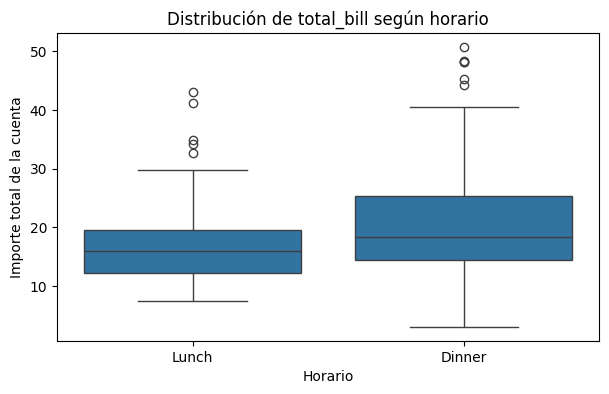

In [13]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="time",
    y="total_bill"
)

plt.title("Distribución de total_bill según horario")
plt.xlabel("Horario")
plt.ylabel("Importe total de la cuenta")

plt.show()

El boxplot muestra que la distribución de `total_bill` en `Dinner` está algo más desplazada hacia valores altos que la de `Lunch`. La mediana de `Dinner` es mayor, y la caja también aparece más extendida, lo que indica más dispersión en la mitad central de los datos.

En ambos horarios aparecen posibles valores extremos hacia importes altos. En `Lunch` hay algunas cuentas por encima de 30 y 40, mientras que en `Dinner` aparecen varios valores altos, incluso cercanos a 50.

Esta visualización complementa la tabla anterior: en este dataset, las cuentas de `Dinner` tienden a ser más altas que las de `Lunch`, pero también hay bastante variación dentro de cada horario. Además, como `Dinner` tiene muchos más registros, conviene no interpretar la cantidad de valores extremos sin recordar el tamaño de cada grupo.

## Relacionar importe total y propina

Hasta ahora analizamos distribuciones y comparaciones entre grupos. Ahora vamos a mirar una relación entre dos variables numéricas: `total_bill` y `tip`.

La pregunta será: **¿las cuentas más altas suelen estar asociadas con propinas más altas?**

Para responderla, vamos a construir un gráfico de dispersión. Cada punto representará una cuenta del dataset.

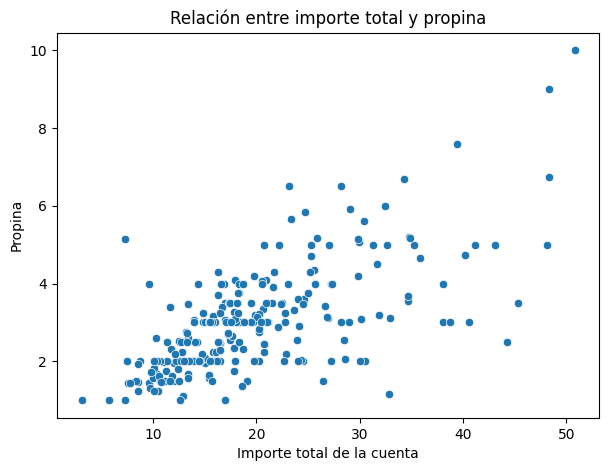

In [14]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Relación entre importe total y propina")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Propina")

plt.show()

El gráfico de dispersión muestra la relación entre el importe total de la cuenta y la propina. Cada punto representa una cuenta del dataset.

La nube de puntos tiene una tendencia ascendente: en general, las cuentas con mayor `total_bill` tienden a estar asociadas con propinas más altas. Sin embargo, la relación no es perfecta. Para importes similares pueden aparecer propinas distintas, y también hay algunos puntos alejados del patrón general.

Esta visualización permite formular un hallazgo prudente: en este dataset, las cuentas más altas suelen estar asociadas con propinas más altas. No estamos diciendo que todos los casos sigan exactamente esa regla, ni que el importe total explique por sí solo el monto de la propina.

## Medir la relación con correlación

Para complementar la lectura visual, vamos a calcular la correlación entre `total_bill` y `tip`.

La correlación resume la relación lineal entre dos variables numéricas. Sus valores van de -1 a 1: los valores positivos indican que ambas variables tienden a aumentar juntas, los valores negativos indican que una tiende a aumentar cuando la otra disminuye, y los valores cercanos a 0 indican poca relación lineal.

In [15]:
correlacion_total_tip = df["total_bill"].corr(df["tip"])

round(float(correlacion_total_tip), 2)

0.68

La correlación entre `total_bill` y `tip` es 0.68. Es un valor positivo, por lo que coincide con la lectura visual del gráfico de dispersión: cuando el importe total de la cuenta aumenta, la propina tiende a aumentar también.

No se trata de una correlación perfecta, porque no vale 1. Esto también coincide con el gráfico: los puntos muestran una tendencia ascendente, pero no están ubicados exactamente sobre una línea.

En el contexto de este análisis exploratorio, podemos decir que existe una relación positiva moderada entre el importe total de la cuenta y la propina. Como siempre, la correlación ayuda a resumir una relación lineal, pero no reemplaza la visualización ni explica por sí sola las causas de esa relación.

## Reunir los principales hallazgos

Después de revisar la estructura del dataset, resumir variables, contar categorías, visualizar distribuciones, comparar grupos y observar relaciones entre variables, podemos reunir algunos hallazgos principales.

En un análisis exploratorio, esta etapa es importante porque nos obliga a pasar de tablas y gráficos aislados a una lectura integrada. La idea no es escribir conclusiones exageradas, sino organizar lo que los datos muestran de manera prudente.

Algunos hallazgos posibles de este análisis son:

- El dataset tiene 244 cuentas registradas y no presenta valores faltantes en sus columnas.
- La mayoría de las cuentas tiene importes bajos o medios, con algunos valores altos menos frecuentes.
- Las propinas también se concentran en valores bajos o medios, aunque aparecen algunos valores altos aislados.
- `Sat` y `Sun` tienen importes promedio de cuenta más altos que `Thur` y `Fri`.
- `Fri` tiene pocos registros, por lo que sus valores deben interpretarse con cuidado.
- `Dinner` tiene más registros que `Lunch` y también presenta importes de cuenta más altos en promedio.
- La distribución de registros por día y horario no es uniforme: `Thur` aparece principalmente en `Lunch`, mientras que `Sat` y `Sun` aparecen solo en `Dinner`.
- Existe una relación positiva entre `total_bill` y `tip`: las cuentas más altas tienden a asociarse con propinas más altas.

## Reconocer límites del análisis

Todo análisis exploratorio tiene límites. Reconocerlos no debilita el trabajo; al contrario, ayuda a interpretar los resultados con más cuidado.

En este caso, estamos trabajando con un dataset pequeño y conocido, usado frecuentemente para practicar análisis de datos. No tenemos fechas completas, información del restaurante, contexto económico, ubicación, menú, precios reales ni detalles sobre cómo se recolectaron los datos.

Por eso, los hallazgos deben leerse como observaciones dentro de este dataset, no como conclusiones generales sobre todos los restaurantes o todos los comportamientos de consumo.

## Cierre del capítulo

En este capítulo integramos varias herramientas de análisis exploratorio. Revisamos la estructura del dataset, diferenciamos variables numéricas y categóricas, calculamos resúmenes, contamos categorías, construimos gráficos de distribución, comparamos grupos y analizamos la relación entre dos variables numéricas.

El recorrido mostró que un análisis exploratorio no es una lista de comandos sueltos. Es una forma ordenada de hacer preguntas, mirar los datos desde distintos ángulos y construir interpretaciones prudentes.

También vimos que las tablas y los gráficos se complementan. Las tablas nos dan valores precisos; los gráficos nos ayudan a ver formas, comparaciones y relaciones. Las conclusiones aparecen cuando conectamos ambas cosas con una pregunta clara.

En el próximo capítulo vamos a trabajar sobre cómo escribir conclusiones a partir de los datos, diferenciando observaciones, interpretaciones y límites.